In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cudf
from cuml import UMAP
import os

In [2]:
# Load the dataset
train_df = pd.read_csv('../../../data/train_resample_standard_all.csv')
val_df = pd.read_csv('../../../data/test_resample_standard_all.csv')


data = pd.concat([train_df, val_df])

# ✅ Extract the ID column (Never modified)
data_id = data["apogee_id"]

# ✅ Extract the Target columns (These are the prediction targets)
data_target = data[["TEFF", "J", "H", "K", "LOGG"]]

# ✅ Define the columns to drop (ID + categorical classifications + unnecessary features)
columns_to_drop = [
    "apogee_id", "TEFF", "J", "H", "K", "LOGG"
]

# Remove unwanted columns
data = data.drop(columns=columns_to_drop)

# ✅ Prepare final dataset for model training
data_scaled = data.copy()

# ✅ Convert to CUDF for GPU processing (if needed)
data_cudf = cudf.DataFrame(data_scaled)

# Display final dataset structure
print("✅ Data Loaded and Preprocessed Successfully!")
print(f"🆔 ID Columns: {data_id.shape}")
print(f"🎯 Target Columns: {data_target.shape}")
print(f"📊 Data for Model: {data_scaled.shape}")

✅ Data Loaded and Preprocessed Successfully!
🆔 ID Columns: (161406,)
🎯 Target Columns: (161406, 5)
📊 Data for Model: (161406, 17)


In [3]:
data.columns

Index(['C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE',
       'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE',
       'FE_H'],
      dtype='object')

In [4]:
print(f"📊 Data for Model: {data_scaled.shape}")
output_folder = "output_dataset"
os.makedirs(output_folder, exist_ok=True)

# List of desired dimensions
dimensions = [2,3,4]

for d in dimensions:
    # Initialize UMAP with 'd' components
    umap_model = UMAP(n_components=d, random_state=42, n_neighbors=80, min_dist=0.005, verbose=True, metric='euclidean')

    # Fit and transform the data with UMAP
    embedding_d = umap_model.fit_transform(data_cudf)

    # Convert the result to a pandas DataFrame
    embedding_d = embedding_d.to_pandas()

    # Add the 'apogee_id' column to retain original identifiers
    embedding_d.insert(0, "apogee_id", data_id)

    # Define the output file name
    output_file = os.path.join(output_folder, f"umap_embedding_{d}D.csv")

    # Save the DataFrame as a CSV file
    embedding_d.to_csv(output_file, index=False)
    print(f"{d}D UMAP embedding saved in {output_file}")

    # Retain the 2D embedding in the variable 'embedding'
    if d == 2:
        embedding = embedding_d


📊 Data for Model: (161406, 17)
[2025-03-25 16:34:11.577] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-03-25 16:34:11.912] [CUML] [debug] n_neighbors=80
[2025-03-25 16:34:11.914] [CUML] [debug] Calling knn graph run
[2025-03-25 16:34:13.505] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-03-25 16:34:13.595] [CUML] [debug] Smooth kNN Distances
[2025-03-25 16:34:13.595] [CUML] [debug] Compute Membership Strength
[2025-03-25 16:34:13.758] [CUML] [debug] Done. Calling remove zeros
2D UMAP embedding saved in output_dataset/umap_embedding_2D.csv
[2025-03-25 16:34:16.773] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-03-25 16:34:16.787] [CUML] [debug] n_neighbors=80
[2025-03-25 16:34:16.789] [CUML] [debug] Calling knn graph run
[2025-03-25 16:34:18.120] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-03-25 16:34:18.132] [CUML] [debug] Smooth kNN Distances
[2025-03-25 16:34:18.133] [CUML] [debug] Compu

In [29]:
embedding.describe()

,0,1
count,161406.000000,161406.000000
mean,0.006738,0.191605
std,6.185876,2.909914
min,-11.296522,-8.189110
25%,-4.439698,-0.994987
50%,-1.888961,0.227430
75%,3.382623,2.373812
max,12.256008,5.368091


In [30]:
#count nan
print(embedding.isna().sum())

apogee_id    0
0            0
1            0
dtype: int64


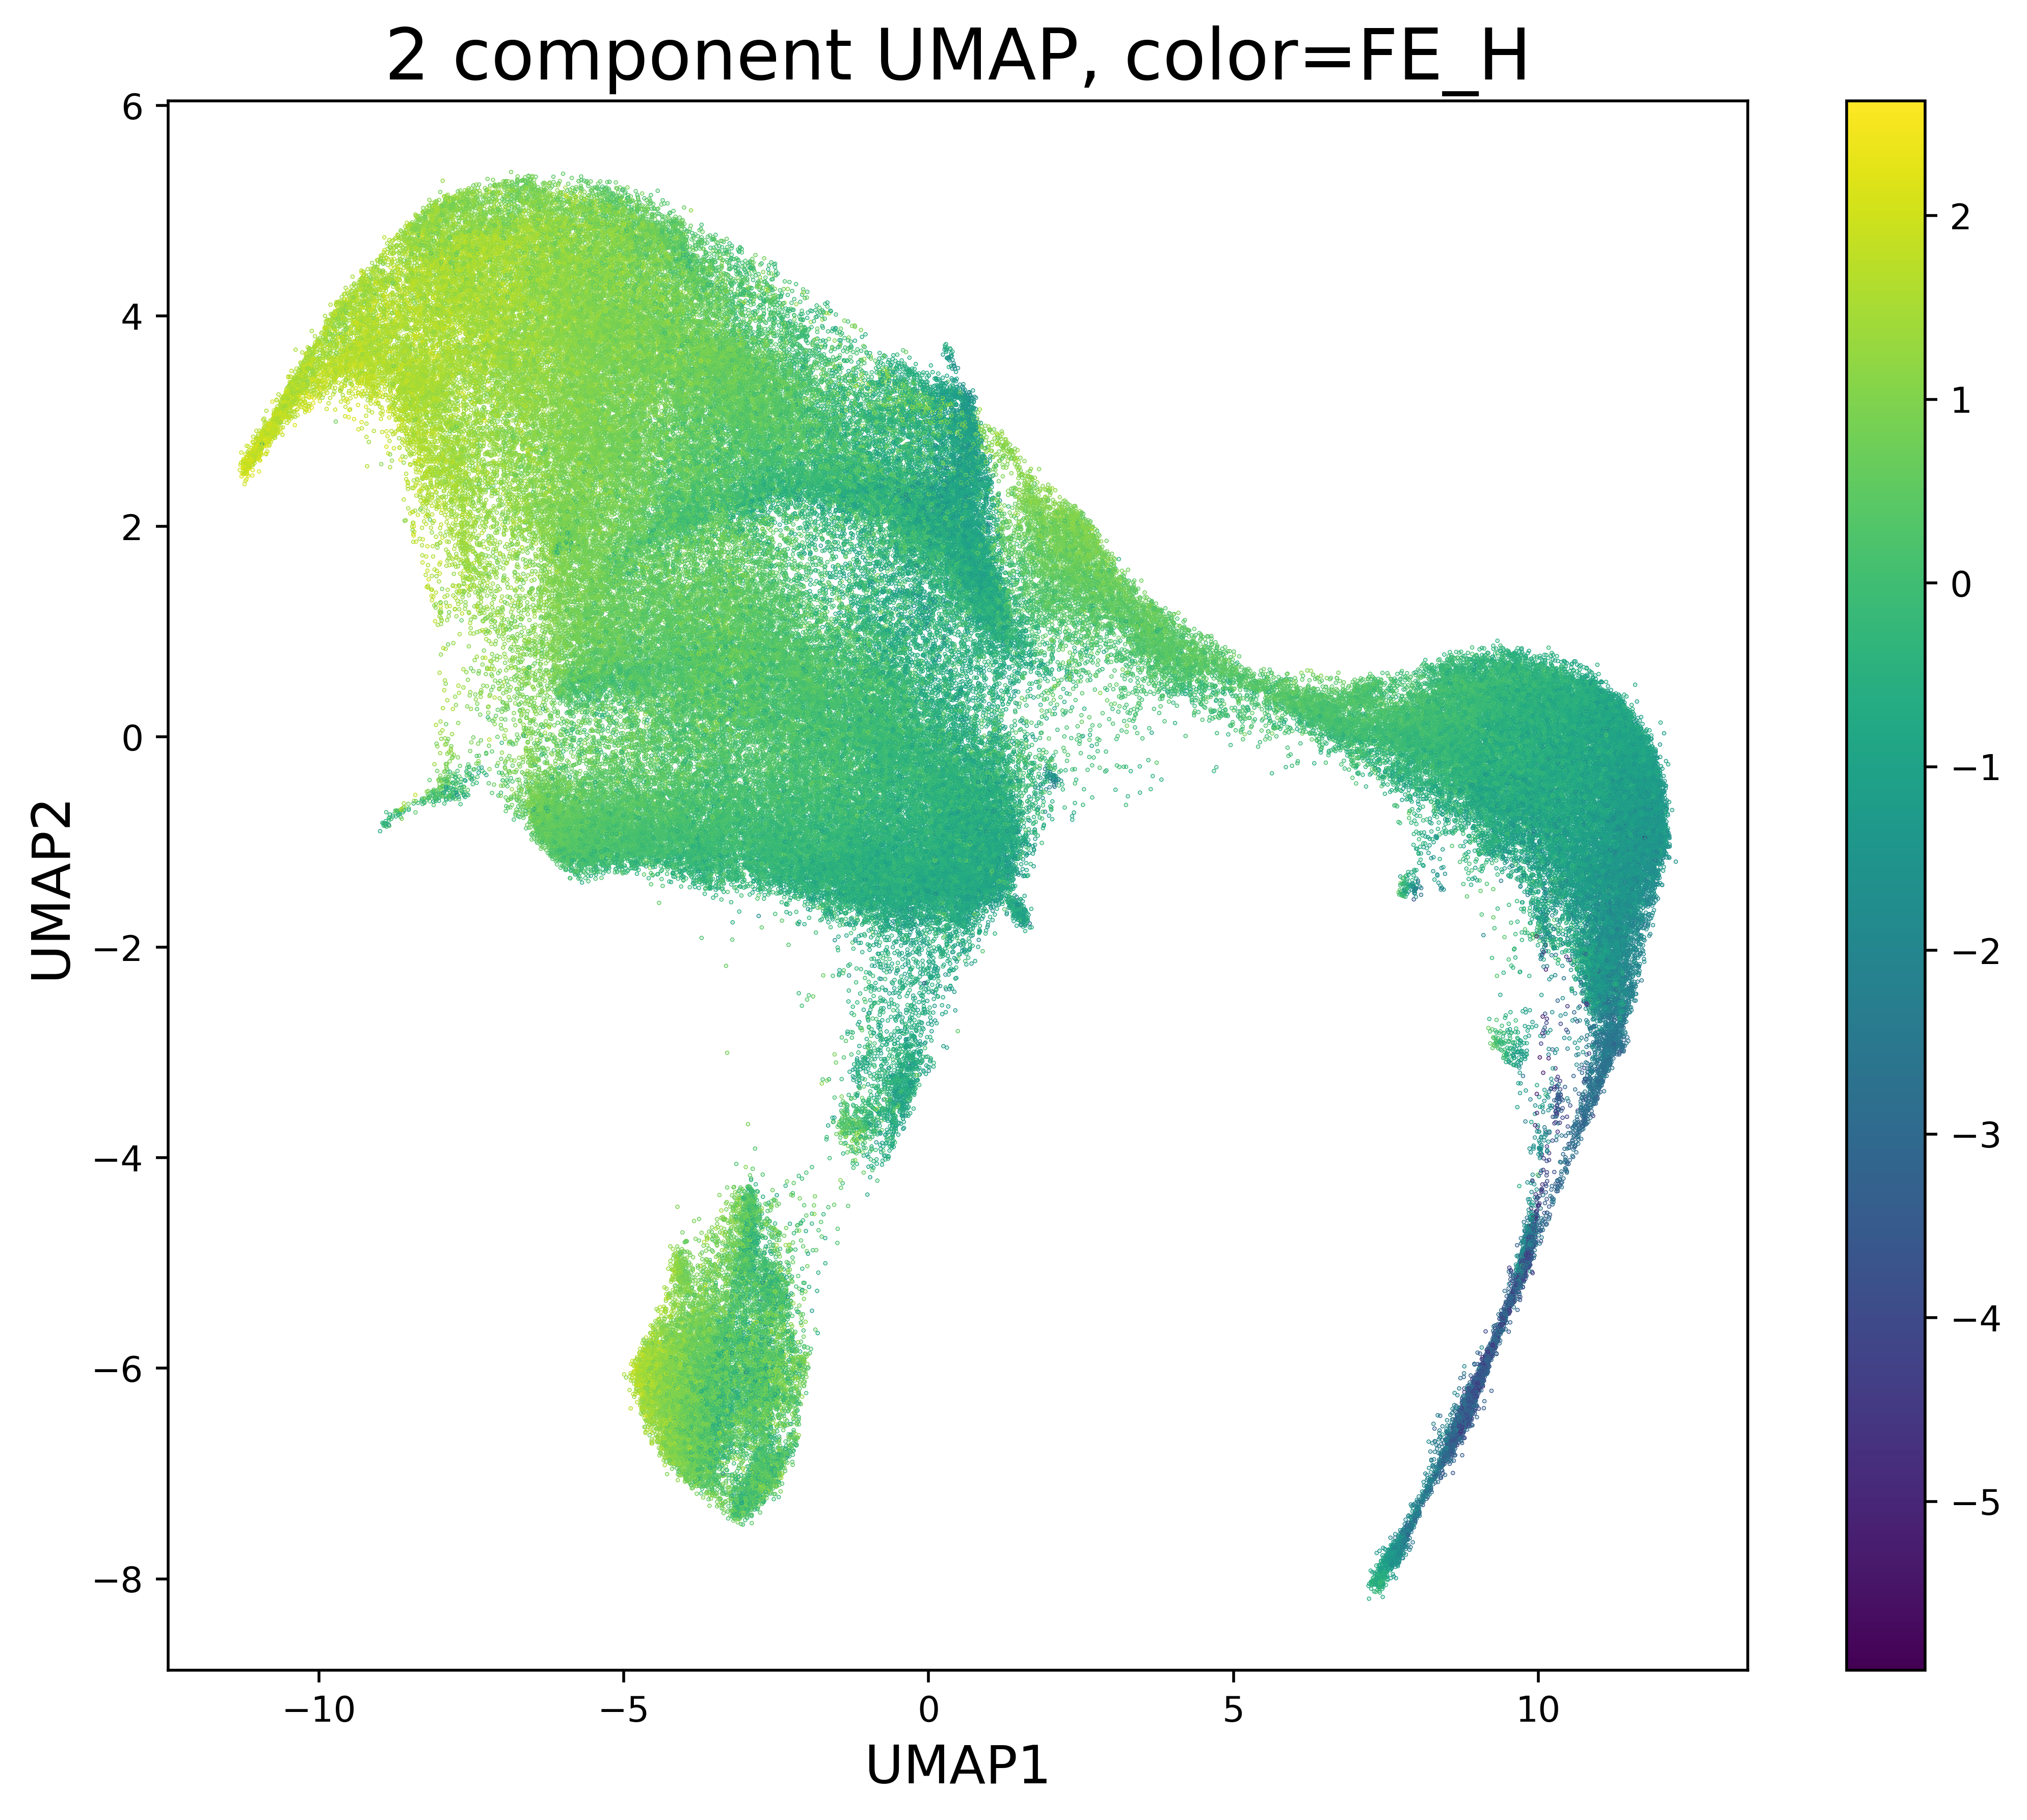

In [31]:
# Plot the results result

fig = plt.figure(figsize=(10,8), dpi=500)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('UMAP1', fontsize=15)
ax.set_ylabel('UMAP2', fontsize=15)
ax.set_title('2 component UMAP, color=FE_H', fontsize=20)
# Create the scatter plot with color gradient from FE_H
scatter = ax.scatter(embedding[0], embedding[1], c=data['FE_H'], cmap='viridis', s=0.05)
plt.colorbar(scatter)
plt.show()
